# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
   
A model is "linear" in its coefficients or parameters. The prediction is made by adding variables multiplied by their coefficients and then it forms a weighted sum plus an intercept.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
   
You interpret the coefficient for a dummy variable as how much the outcome changes compared to the category that was dropped. The intercept represents the expected outcome for the category that was dropped.

3. Can linear regression be used for classification? Explain why, or why not.
   
Yes linear regression can technically be used for classification by setting a threshold (like 0.5) but it isn't ideal. Because it is a global smoothing model that minimizes Mean Squared Error, it can make predictions outside the 0 to 1 range and is really sensitive to outliers, which can lead to unreliable decision boundaries.

4. What are signs that your linear model is over-fitting?
   
Some signs that a linear model is over-fitting are a significant difference between low training error and high test error, and high variance in the coefficients caused having too many overlapping variables/multicollinearity. This happens when the model is too complex and begins to treat random noise as a meaningful pattern.

5. Clearly explain multi-colinearity using the two-stage least squares technique.
   
Multi-collinearity is the problem of having no unique signal left. If your variables overlap too much, the first stage takes away almost everything because it can't tell the difference between the two variables. This leaves the second stage with nothing but noise to work with. This is why the class notes suggest that dropping variables can actually make your model a better and more stable predictor.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
   
You can incorporate nonlinear relationships by transforming the variables before putting them into the model. Such as using polynomials (like squaring a variable to make a curve), log transformations to for exponential data, or where you multiply variables together to see how they influence each other. If the input data is adjusted first it can still fit curved patterns because the model is only "linear" in its coefficients.

7. What is the interpretation of the slope coefficient in a linear regression?
   
The slope coefficient is the average change in the outcome variable for every one unit increase in the independent variable and holds all the other variables constant. It gets the unique signal of that specific feature but basically the model shows that these two things are related, but it doesn't prove that one actually causes the other to change.

8. Compare the train/test split and $k$-fold cross validation.
   
A train/test split is like a quick check where you can hide a portion of the data to see if the model can guess it. K-fold cross validation is like doing that test over and over again with different sections of the data. While train/test split is faster, k-fold is better because it gives a more consistent and reliable measure of the model's actual performance.

9.  How is the $k$ in $k$-fold cross validation typically selected?
    
The value of k is commonly chosen as 5 or 10. This is because they have been shown to give the most reliable balance between bias and variable and they give enough testing rounds to make sure the model is reliable. It is the most common way to get an accurate estimate of a model's performance on most datasets.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skimpy as skim

In [6]:
df = pd.read_csv('/Users/clairicelou/Documents/DS3021/scratchpad/data/Q1_clean.csv', encoding='latin1')

df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


### Q2, 1

In [10]:
print(df.columns)

Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='str')


In [12]:
df.columns = df.columns.str.strip()

In [14]:
average = df.groupby('Neighbourhood')[['Price','Review Scores Rating']].mean()
print(average)

most_expensive = average['Price'].idxmax()
print("Most expensive borough on average:", most_expensive)

                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750
Most expensive borough on average: Manhattan


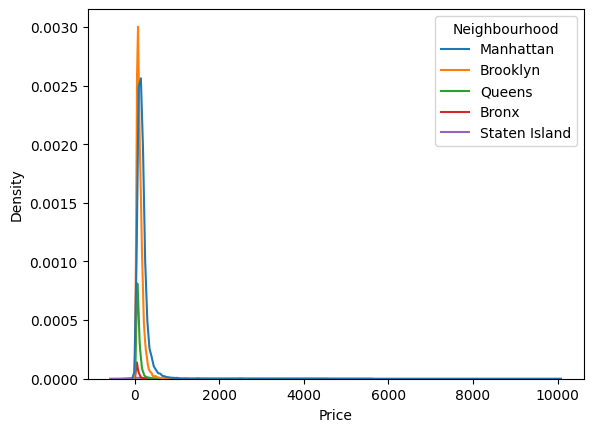

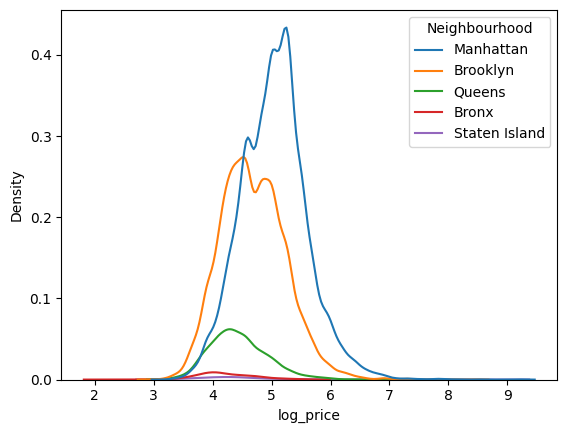

In [15]:
sns.kdeplot(data=df, x='Price', hue='Neighbourhood')
plt.show()

df['log_price'] = np.log(df['Price'])

sns.kdeplot(data=df, x='log_price', hue='Neighbourhood')
plt.show()

### Q2, 2

In [16]:
from sklearn.linear_model import LinearRegression

y = df['Price']

X = pd.get_dummies(df['Neighbourhood'], dtype='int', drop_first=True)

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)

pd.DataFrame({'variable': model.feature_names_in_,'coefficient': model.coef_})

Intercept: 75.27649769584667


,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


I made dummy variables for Neighbourhood using pd.get_dummies(..., drop_first=True) to avoid the dummy variable trap. The dropped borough becomes the baseline group, so the intercept represents its average price. Each coefficient represents the difference in average price between that borough and the baseline borough. So the regression coefficients correspond to the conditional group means from part 1: the mean price for each borough equals the intercept plus its coefficient.

### Q2, 3

In [ ]:
from sklearn.linear_model import LinearRegression

y = df['Price']

X = df[['Review Scores Rating']]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)

pd.DataFrame({'variable': model.feature_names_in_,'coefficient': model.coef_})

Intercept: 60.878390657123816


,variable,coefficient
0,Review Scores Rating,1.020827


The slope coefficient is the change in expected price for a one unit increase in Review Scores Rating. So a one point increase in rating is associated with a β dollar change in the average nightly price.

### Q2, 4

In [19]:
y = df['Price']

X_rating = df[['Review Scores Rating']]

X_neigh = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype='int')

X = pd.concat([X_rating, X_neigh], axis=1)

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)

pd.DataFrame({'variable': model.feature_names_in_,'coefficient': model.coef_})

Intercept: -23.812561011673182


,variable,coefficient
0,Review Scores Rating,1.081116
1,Brooklyn,51.704240
2,Manhattan,108.228737
3,Queens,21.694600
4,Staten Island,71.766552


When Review Scores Rating is added to the regression the slope coefficient measures how price changes with rating and holds neighborhood constant. Compared to the single regression, the coefficient may change because neighborhood differences in price are now accounted for. The neighborhood coefficients now represent differences in average price between boroughs for listings with the same review rating.

### Q2, 5

In [20]:
y = df['Price']
X_neigh = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype='int')

X_interactions = X_neigh.mul(df['Review Scores Rating'], axis=0)
X_interactions.columns = [col + "_rating_slope" for col in X_interactions.columns]

X = pd.concat([df[['Review Scores Rating']], X_interactions], axis=1)

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)

pd.DataFrame({"variable": model.feature_names_in_,"coefficient": model.coef_})

Intercept: 55.118253641163506


,variable,coefficient
0,Review Scores Rating,0.222718
1,Brooklyn_rating_slope,0.568229
2,Manhattan_rating_slope,1.176658
3,Queens_rating_slope,0.233733
4,Staten Island_rating_slope,0.459726


The slopes are not identical across neighborhoods. The baseline borough has a slope of about 0.22, while the slopes for the other boroughs range from about 0.46 to 1.40. Manhattan shows the largest slope, so higher review scores are associated with larger increases in price there. So the slopes differ across neighborhoods showing that the relationship between ratings and price varies by location.

### Q2, 6

In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

X4 = pd.concat([df[['Review Scores Rating']],pd.get_dummies(df['Neighbourhood'], drop_first=True)], axis=1)
y = df['Price']
model = LinearRegression()
scores4 = cross_val_score(model, X4, y, cv=5, scoring='neg_mean_squared_error')
print("Model 4 Cross Validation MSE:", -scores4.mean())

Model 4 Cross Validation MSE: 21113.112422262097


In [25]:
X_neigh = pd.get_dummies(df['Neighbourhood'], drop_first=True)

X_interact = X_neigh.mul(df['Review Scores Rating'], axis=0)
X_interact.columns = [c + "_rating" for c in X_interact.columns]

X5 = pd.concat([df[['Review Scores Rating']], X_interact], axis=1)

scores5 = cross_val_score(model, X5, y, cv=5, scoring='neg_mean_squared_error')
print("Model 5 Cross Validation MSE:", -scores5.mean())

Model 5 Cross Validation MSE: 21086.423844673594


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


### Q3, 1

In [31]:
cars = pd.read_csv('/Users/clairicelou/Documents/DS3021/scratchpad/data/cars_hw.csv', encoding='latin1')

cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [43]:
cars['Price'].describe()

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

<Axes: ylabel='Density'>

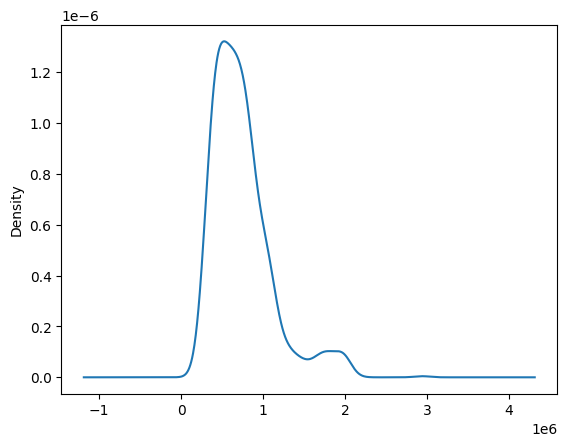

In [41]:
cars['Price'].plot.kde()

In [44]:
cars.groupby('Body_Type')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


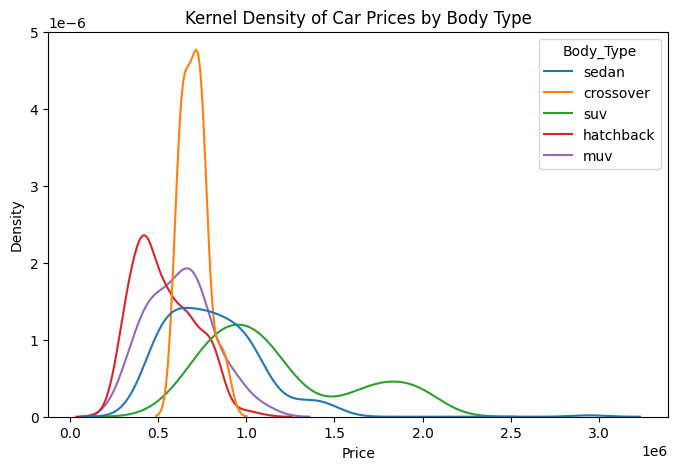

In [49]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=cars, x='Price', hue='Body_Type', common_norm=False)
plt.title('Kernel Density of Car Prices by Body Type')
plt.xlabel('Price')
plt.show()

SUVs are the most expensive and have the highest variance, but sedans have a higher density of prices around their mean, which is why their KDE peak is the tallest.

### Q3, 2

In [51]:
from sklearn.linear_model import LinearRegression
import pandas as pd

y = cars['Price']
X = pd.get_dummies(cars['Seating_Capacity'], drop_first=True) 

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)

pd.DataFrame({'variable': X.columns, 'coefficient': model.coef_})

Intercept: 188000.00000000163


,variable,coefficient
0,5,5.464839e+05
1,6,1.456000e+06
2,7,7.359487e+05
3,8,2.718000e+05


The price does not increase linearly with the number of seats. Some seat increments (like 5 to 6) increase price much more than others, while others (like 7 to 8) increase it only a little. This means that there is a nonlinear relationship.

### Q3, 3

In [53]:
cars['Age'] = 2026 - cars['Make_Year']

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures

y = cars['Price']

# degree 1
poly1 = PolynomialFeatures(degree=1, include_bias=False)
X1 = poly1.fit_transform(cars[['Age']])
model = LinearRegression()
cv1 = cross_val_score(model, X1, y, cv=10, scoring='neg_mean_squared_error')
mse1 = -cv1.mean()

# degree 2
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X2 = poly2.fit_transform(cars[['Age']])
cv2 = cross_val_score(model, X2, y, cv=10, scoring='neg_mean_squared_error')
mse2 = -cv2.mean()

# degree 3
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X3 = poly3.fit_transform(cars[['Age']])
cv3 = cross_val_score(model, X3, y, cv=10, scoring='neg_mean_squared_error')
mse3 = -cv3.mean()

print("Degree 1 CV MSE:", mse1)
print("Degree 2 CV MSE:", mse2)
print("Degree 3 CV MSE:", mse3)

Degree 1 CV MSE: 100295370079.45541
Degree 2 CV MSE: 100814620596.42152
Degree 3 CV MSE: 100380163091.91902


### Q3, 4

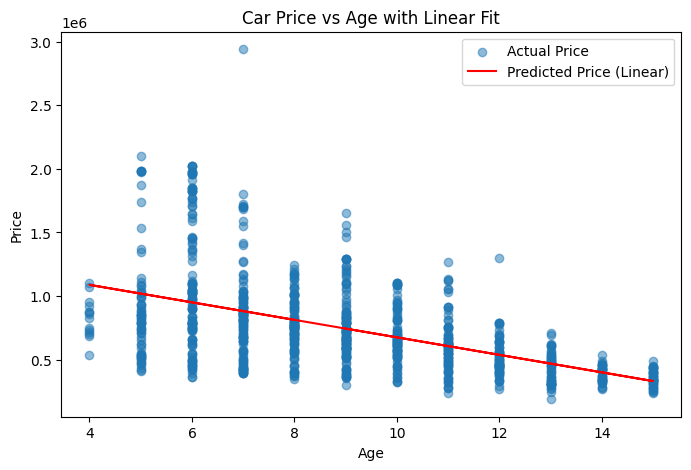

In [55]:
X = cars[['Age']]
y = cars['Price']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.figure(figsize=(8,5))
plt.scatter(cars['Age'], y, alpha=0.5, label='Actual Price')
plt.plot(cars['Age'], y_pred, color='red', label='Predicted Price (Linear)')
plt.xlabel('Age')
plt.ylabel('Price')
plt.title('Car Price vs Age with Linear Fit')
plt.legend()
plt.show()

The model roughly shows the downward trend that older cars are cheaper but it doesn’t fit the data very well. Most of the points are spread above and below the predicted line, and the spread seems to get smaller as age increases, so the model misses some of the variation in prices.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [7]:
heart = pd.read_csv('/Users/clairicelou/Documents/DS3021/scratchpad/data/heart_hw.csv', encoding='latin1')

heart.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


### Q4, 1

In [27]:
a = heart.loc[heart['transplant'] == 'control', 'y'].mean()
b = heart.loc[heart['transplant'] == 'treatment', 'y'].mean()

ATE = b - a

print("Control survival rate:", a)
print("Treatment survival rate:", b)
print("ATE:", ATE)

Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE: 0.23017902813299232


### Q4, 2

In [28]:
from sklearn.linear_model import LinearRegression
import pandas as pd

y = heart['y']
X = pd.get_dummies(heart['transplant'], drop_first=True)

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)

pd.DataFrame({'variable': model.feature_names_in_,'coefficient': model.coef_})

Intercept: 0.11764705882352941


,variable,coefficient
0,treatment,0.230179


### Q4, 3

In [29]:
from sklearn.linear_model import LinearRegression

y = heart['y']

X_age = heart[['age']]
X_transplant = pd.get_dummies(heart['transplant'], drop_first=True, dtype='int')

X = pd.concat([X_age, X_transplant], axis=1)

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)

pd.DataFrame({'variable': model.feature_names_in_,'coefficient': model.coef_})

Intercept: 0.7019569721740946


,variable,coefficient
0,age,-0.013607
1,treatment,0.264702


How does the coefficient on transplant change when you control for age? What do the intercept and slope represent? 

The coefficient on transplant changes when you control for age because when age is included in the regression, the coefficient on transplant increases from the ATE of 0.230 to about 0.265 so the controlling for age slightly increases the estimated effect of receiving a transplant on 3 year survival. The intercept represents the predicted probability of survival for a control patient when age equals zero. The age slope represents the change in the predicted probability of survival for a 1 year increase in age. And it holds transplant status constant while the transplant coefficient represents the difference in survival probability between treatment and control patients of the same age.

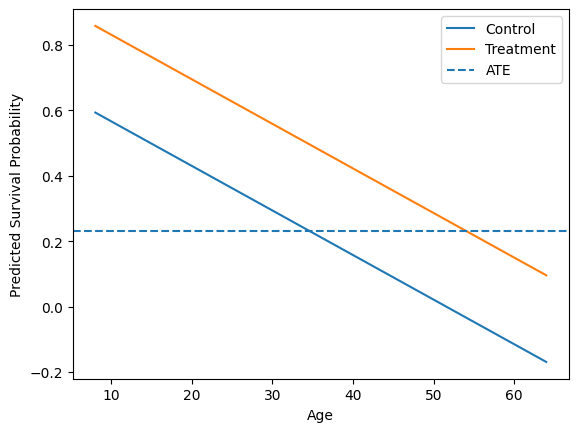

In [30]:
ages = np.linspace(heart['age'].min(), heart['age'].max(), 100)

pred_control = model.intercept_ + model.coef_[0]*ages
pred_treat = pred_control + model.coef_[1]

plt.plot(ages, pred_control, label='Control')
plt.plot(ages, pred_treat, label='Treatment')

ATE = heart.groupby('transplant')['y'].mean()['treatment'] - heart.groupby('transplant')['y'].mean()['control']
plt.axhline(ATE, linestyle='--', label='ATE')

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.legend()
plt.show()

Looking at the graph, the vertical distance between the treatment and control lines is slightly less than the ATE dashed line (about 0.230). This means that the ATE slightly overestimates the impact of a transplant for all ages because the age adjusted effect is actually a bit smaller than the simple average.

### Q4, 4

In [33]:
from sklearn.linear_model import LinearRegression

y = heart['y']

X_age = heart[['age']]
X_transplant = pd.get_dummies(heart['transplant'], drop_first=True, dtype='int')  

X_interact = pd.DataFrame(X_age['age'] * X_transplant['treatment'], columns=['age_treatment'])

X = pd.concat([X_age, X_transplant, X_interact], axis=1)

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
pd.DataFrame({'variable': model.feature_names_in_, 'coefficient': model.coef_})


Intercept: 0.3548651752994728


,variable,coefficient
0,age,-0.005524
1,treatment,0.907751
2,age_treatment,-0.014591


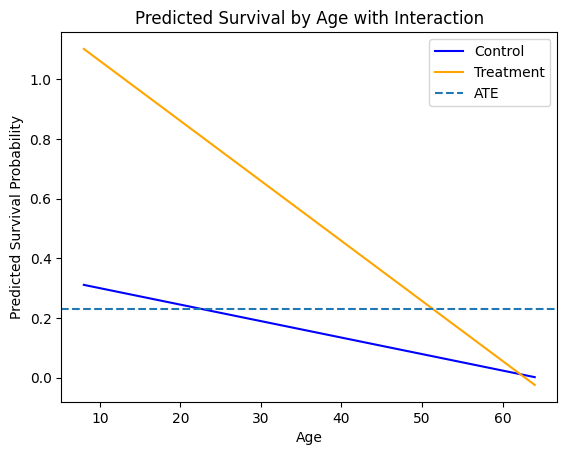

In [37]:
ages = np.linspace(heart['age'].min(), heart['age'].max(), 100)

pred_control = model.intercept_ + model.coef_[0]*ages
pred_treat = model.intercept_ + model.coef_[0]*ages + model.coef_[1] + model.coef_[2]*ages

plt.plot(ages, pred_control, label='Control', color='blue')
plt.plot(ages, pred_treat, label='Treatment', color='orange')
plt.axhline(0.230, linestyle='--', label='ATE')
plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.title("Predicted Survival by Age with Interaction")
plt.legend()
plt.show()

How does allowing age and transplant to interact change your predictions? What pattern do you notice?

Allowing age and transplant to interact changes the predictions by letting the transplant effect vary with age. In the graph the treatment line is no longer parallel to the control line. It starts high for younger patients and declines with age. This shows that younger patients benefit a lot more from a transplant while the benefit decreases as patients get older.

### Q4, 5

In [38]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Model 1 transplant only
X1 = pd.get_dummies(heart['transplant'], drop_first=True, dtype='int')
cv1 = cross_val_score(model, X1, y, cv=10, scoring='neg_mean_squared_error')
mse1 = -cv1.mean()

# Model 2 transplant and age
X2 = pd.concat([heart[['age']], X1], axis=1)
cv2 = cross_val_score(model, X2, y, cv=10, scoring='neg_mean_squared_error')
mse2 = -cv2.mean()

# Model 3 transplant and age and interaction
X3 = X2.copy()
X3['age_treatment'] = heart['age'] * X1['treatment']
cv3 = cross_val_score(model, X3, y, cv=10, scoring='neg_mean_squared_error')
mse3 = -cv3.mean()

print("Model 1 CV MSE:", mse1)
print("Model 2 CV MSE:", mse2)
print("Model 3 CV MSE:", mse3)

Model 1 CV MSE: 0.20970277289824915
Model 2 CV MSE: 0.19922806049232317
Model 3 CV MSE: 0.19609811380122782


### Q4, 6

Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

I would be concerned about several things. The predictions are based on correlations, not guaranteed effects, so it might over or under estimate who benefits. It could unfairly disadvantage older patients or miss other important health factors, and using it without care could create bias in who gets access.